In [1]:
!pip install seaborn

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("08-email_classification_svm.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [5]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [6]:
df["email_type"].unique()

array([0, 1])

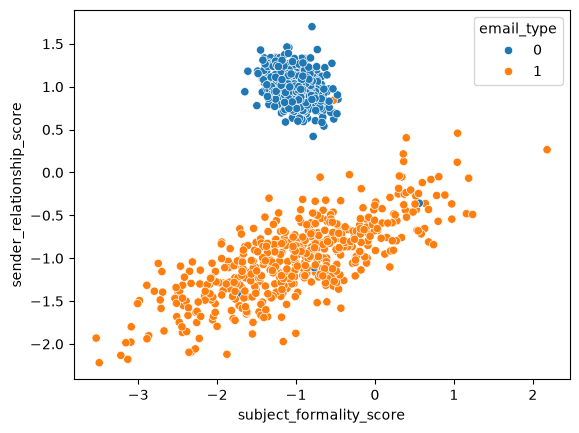

In [7]:
sns.scatterplot(x= df["subject_formality_score"],y=df["sender_relationship_score"],hue=df["email_type"])
plt.show()

In [8]:
X = df[["subject_formality_score","sender_relationship_score"]].values
y = df["email_type"].values

In [9]:
X

array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]], shape=(1000, 2))

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [14]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [15]:
X_train.ndim

2

In [16]:
y_train.ndim

2

In [17]:
from torch import nn

In [18]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)

    def forward(self,x):
        return self.layer2(self.layer1(x))

In [19]:
model_0 = ClassificationModel()

In [20]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)

In [21]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item()
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [22]:
y_logits = model_0(X_test)[:10]

In [23]:
y_pred_probs = torch.sigmoid(y_logits)

In [24]:
y_pred_probs

tensor([[0.3676],
        [0.5567],
        [0.3746],
        [0.5720],
        [0.3686],
        [0.5657],
        [0.5905],
        [0.3259],
        [0.3104],
        [0.5980]], grad_fn=<SigmoidBackward0>)

In [25]:
y_preds = torch.round(y_pred_probs)

In [26]:
y_preds

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.]], grad_fn=<RoundBackward0>)

In [27]:
y_test[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [28]:
calculate_accuracy(y_test[:10],y_preds)

100.0

In [29]:
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train)
    acc = calculate_accuracy(y_test= y_train, y_pred = y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test= y_test, y_pred = test_pred)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Acc: {test_acc}")

Epoch: 0, Loss: 0.49448907375335693, Accuracy: 97.625, Test Loss: 0.486357182264328, Test Acc: 98.5
Epoch: 5, Loss: 0.4854487180709839, Accuracy: 98.25, Test Loss: 0.4773314595222473, Test Acc: 99.0
Epoch: 10, Loss: 0.4765866994857788, Accuracy: 98.625, Test Loss: 0.4684734642505646, Test Acc: 99.5
Epoch: 15, Loss: 0.4678814709186554, Accuracy: 98.625, Test Loss: 0.4597628116607666, Test Acc: 99.5
Epoch: 20, Loss: 0.4593162536621094, Accuracy: 98.625, Test Loss: 0.4511834681034088, Test Acc: 99.5
Epoch: 25, Loss: 0.4508780241012573, Accuracy: 98.625, Test Loss: 0.44272303581237793, Test Acc: 100.0
Epoch: 30, Loss: 0.4425569176673889, Accuracy: 98.625, Test Loss: 0.43437275290489197, Test Acc: 100.0
Epoch: 35, Loss: 0.43434569239616394, Accuracy: 98.75, Test Loss: 0.42612606287002563, Test Acc: 100.0
Epoch: 40, Loss: 0.42623957991600037, Accuracy: 98.75, Test Loss: 0.4179788827896118, Test Acc: 100.0
Epoch: 45, Loss: 0.4182354807853699, Accuracy: 98.75, Test Loss: 0.4099288284778595, Te

In [30]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

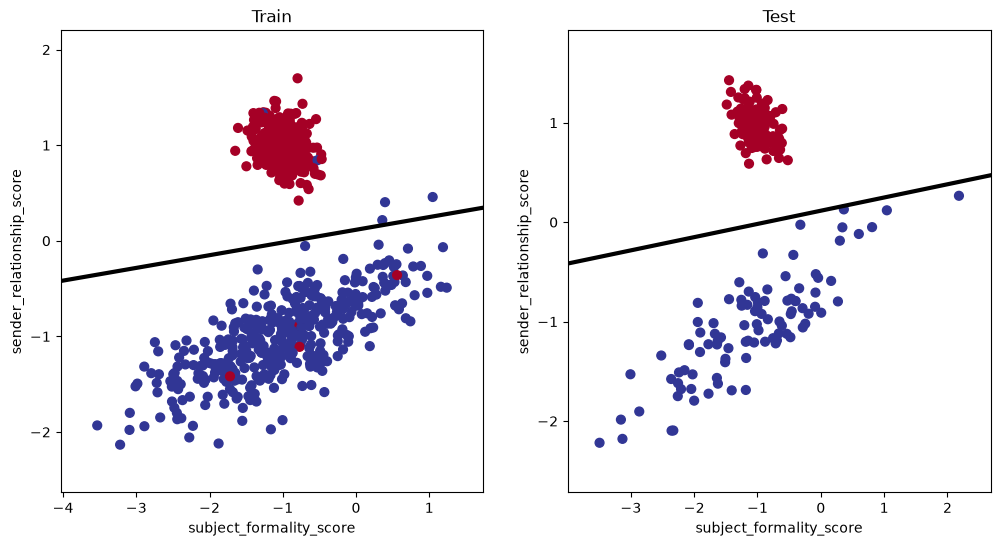

In [31]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)

plt.show()